In [63]:
import os
import sys

# from pathlib import Path
import numpy as np
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from libs.config.config_variables import STORAGE_DIR
from modules.seismo_response.class_curves import (
                                                Curve, 
                                                GGmax_Curve,
                                                Damping_Curve,
                                                Multiple_Curves,
                                                Multiple_GGmax_Damping_Curves,
                                                )

session = "sesion_20260223_103200_ew"
input_dir = STORAGE_DIR / "raw_data" / session / "dynamic_curves.txt"

## Manejo de la clase Curves

### Data

In [43]:
ggmax_input = np.array([
                [0.0001, 0.983],
                [0.0003, 0.958],
                [0.001, 0.894],
                [0.003, 0.769],
                [0.01, 0.548],
                [0.03, 0.325],
                [0.1, 0.149],
                [0.3, 0.065],
                [0.7, 0.033],
                [1, 0.025],
                [3, 0.010],
                [7, 0.005],
                [10, 0.004],
                ])

damping_input = np.array([
                [0.0001, 0.76],
                [0.0003, 1.15],
                [0.001, 1.81],
                [0.003, 2.73],
                [0.01, 4.27],
                [0.03, 6.41],
                [0.1, 9.82],
                [0.3, 13.92],
                [0.7, 17.30],
                [1, 18.60],
                [3, 21.66],
                [7, 22.95],
                [10, 23.28],
                ])

#### Se puede utilizar curves para guardar una curva dinámica sin importar su tipo de data, pero se aceptan 3 casos:
- $\gamma$ vs $\tau$
- $\gamma$ vs $G/G_{máx}$
- $\gamma$ vs $D$

In [45]:
# Uso de clase curve
curve_1 = Curve(ggmax_input, strain_unit="%")
curve_2 = Curve(damping_input, strain_unit="%")

(<Figure size 300x300 with 1 Axes>,
 <Axes: xlabel='Strain [%]', ylabel='G/Gmax'>)

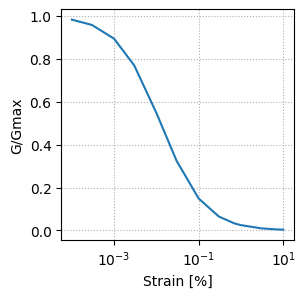

In [48]:
curve_1.plot(
    ylabel="G/Gmax"
)

In [60]:
GGmax_data = GGmax_Curve(ggmax_input, strain_unit="%")
Damp_data = Damping_Curve(damping_input, 
                          strain_unit="%",
                          damping_unit="%")

{
  gamma_ref: 11552.362452330599,
  s: 0.5856815826692484,
  beta: 14018.648679357188,
  Gmax: 1.0
}

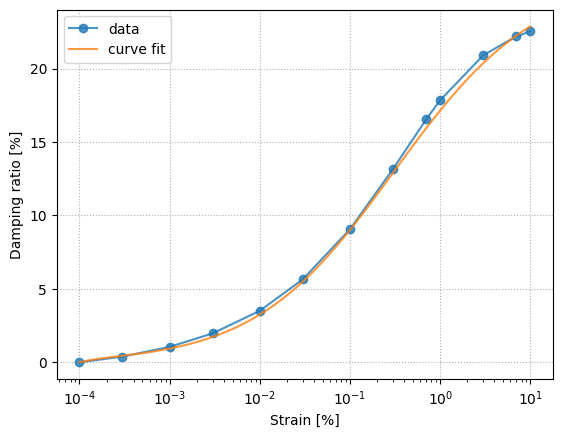

In [ ]:
# Con el .get_... se puede ajustar una curva dinámica a un modelo.
Damp_data.get_H4_x_param(show_fig=True) # Ajustado al MKZ

In [ ]:
curvas_multiples = Multiple_Curves()

(<Figure size 300x300 with 1 Axes>, <Axes: xlabel='Strain [%]'>)

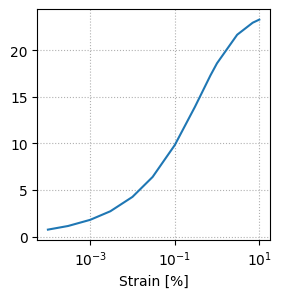

In [55]:
Damp_data.plot()

In [65]:
print(input_dir)

c:\Users\william.ortiz\OneDrive - ANDDES ASOCIADOS SAC\Otros\Escritorio\Proyectos GITLAB\PRISMO_GITLAB\prismo\var\raw_data\sesion_20260223_103200_ew\dynamic_curves.txt


In [66]:
multiples_curvas = Multiple_GGmax_Damping_Curves(data=str(input_dir))

In [76]:
mgc, mdc = multiples_curvas.get_MGC_MDC_objects()

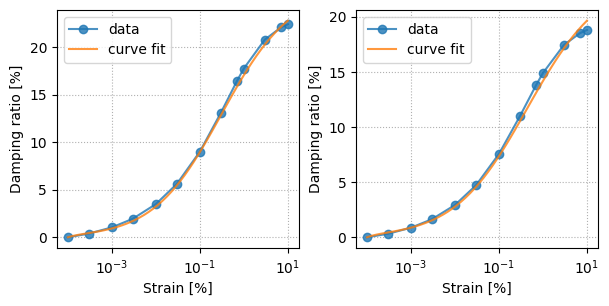

In [ ]:
mdc.get_all_H4_x_params(show_fig=True)
mdc.